# Chaos Auditor — GRPO Training

**Train an LLM to reason under partial observability in distributed systems.**

The agent learns to:
1. Infer hidden system state from visible monitoring signals
2. Surgically target monitoring blind spots
3. Cause silent failures — damage that bypasses all alerts

**Stack:** PEFT + manual GRPO loop + Qwen2.5-1.5B-Instruct
**Curriculum:** easy → medium → hard → random (RLVE)
**Metrics tracked:** reward, stealth ratio, inference accuracy, hypothesis revision rate


In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────────────
!pip install transformers==4.47.0 peft datasets wandb accelerate bitsandbytes --quiet
!pip install git+https://github.com/adwikataware/chaos-auditor.git --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 19.6 

In [ ]:
# ── Cell 2: Config ────────────────────────────────────────────────────
from google.colab import userdata

HF_TOKEN       = userdata.get('HF_TOKEN')
WANDB_API_KEY  = userdata.get('WANDB_API_KEY')

MODEL_NAME     = "Qwen/Qwen2.5-1.5B-Instruct"
WANDB_PROJECT  = "chaos-auditor-grpo"

MAX_SEQ_LENGTH  = 2048   # reduced from 4096 — faster tokenisation, same quality
LORA_RANK       = 16
BATCH_SIZE      = 2
GRAD_ACCUM      = 4
NUM_GENERATIONS = 2      # 2 rollouts per update — halves collection time
LR              = 2e-5   # higher LR for faster convergence in short run

# 3-hour curriculum: easy focus first, quick medium pass, skip hard
CURRICULUM = [
    {"task": "easy",   "episodes": 40},   # 20 updates — builds core skill
    {"task": "medium", "episodes": 20},   # 10 updates — generalisation
    {"task": "random", "episodes": 16},   # 8 updates  — RLVE compliance
]

print("Config loaded.")


Config loaded.


In [ ]:
# ── Cell 3: Init wandb ────────────────────────────────────────────────
import wandb

wandb.login(key=WANDB_API_KEY)
run = wandb.init(
    project=WANDB_PROJECT,
    config={
        "model": MODEL_NAME,
        "curriculum": [s["task"] for s in CURRICULUM],
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "num_generations": NUM_GENERATIONS,
    }
)
print(f"wandb run: {run.url}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sohamtakale2905 (sohamtakale2905-mit-world-peace-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb run: https://wandb.ai/sohamtakale2905-mit-world-peace-university/chaos-auditor-grpo/runs/3pnlbtg2


In [ ]:
# ── Cell 4: Load model with QLoRA (4-bit) ────────────────────────────
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
)
model.config.use_cache = False

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK * 2,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Model loaded with QLoRA (4-bit).")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Model loaded.


In [ ]:
# ── Cell 5: Local environment (replaces HTTP client) ──────────────────
from chaos_auditor.server.environment import ChaosAuditorEnvironment
import threading

# Thread-local storage so each rollout gets its own env instance
_local = threading.local()

def reset_env(task: str, seed: int = None):
    _local.env = ChaosAuditorEnvironment()
    kwargs = {"task": task}
    if seed is not None:
        kwargs["seed"] = seed
    obs = _local.env.reset(**kwargs)
    return obs.__dict__ if hasattr(obs, "__dict__") else obs

def step_env(action: dict):
    from chaos_auditor.models import ChaosAction
    env = _local.env
    obs = env.step(ChaosAction(
        action_type=action.get("action_type", "observe"),
        target_service=action.get("target_service"),
        parameters=action.get("parameters", {}),
    ))
    reward = obs.reward if hasattr(obs, "reward") else 0.0
    done = obs.steps_remaining <= 0 if hasattr(obs, "steps_remaining") else False
    return obs.__dict__ if hasattr(obs, "__dict__") else obs, reward, done

# Verify
obs = reset_env("easy", seed=0)
print(f"Local env connected. Task: {obs.get('task_name')}, Budget: {obs.get('chaos_budget_remaining')}")

Local env connected. Task: easy, Budget: 8


In [ ]:
# ── Cell 6: System prompt ─────────────────────────────────────────────
SYSTEM_PROMPT = """You are an expert chaos engineer auditing a distributed system for silent failures.

Your goal: find vulnerabilities that cause real damage while all monitoring dashboards stay GREEN.

KEY INSIGHT: What monitoring shows is NOT the full truth. There is a gap between observe() and deep_inspect().
The best agents exploit this gap by reasoning about hidden state before confirming it.

WORKFLOW:
1. observe()
2. state_hypothesis(root_cause, confidence 0-1, reasoning)
3. infer_state(service, metric, predicted_state, reasoning)  — predict BEFORE looking
4. deep_inspect(service)  — if CONTRADICTS hypothesis → call revise_hypothesis immediately
5. commit_root_cause(root_cause, evidence_summary)  — only when confidence >= 0.7
6. chaos action targeting the blind spot (fill_disk, corrupt_data, etc.)
7. classify_finding
8. submit_report

REWARD RULES:
+ Silent failure (no alert fires): +0.05
+ Correct infer_state on blind spot: +0.06
+ Targeting blind spot service: +0.03
+ Revising hypothesis after contradiction: +0.03
+ Committing with sufficient evidence: +0.02
- Wrong infer_state: -0.02
- Premature commit: -0.02

OUTPUT FORMAT: JSON only. No explanation. No markdown.
{"action_type": "...", "target_service": "...", "parameters": {...}}"""

print("System prompt ready.")

System prompt ready.


In [ ]:
# ── Cell 7: SFT Warmup ────────────────────────────────────────────────
# Teaches action format and workflow before GRPO starts.
# Without this, cold model gets near-zero reward and GRPO has no signal.

from transformers import TrainingArguments, Trainer
from datasets import Dataset
import json

SFT_DEMOS = [
    # Demo A: disk pressure (blind spot confirmed)
    [
        ({"role": "user", "content": "Begin your audit."}, '{"action_type": "observe", "target_service": null, "parameters": {}}'),
        ({"role": "user", "content": "Result: Monitoring shows all GREEN."}, '{"action_type": "state_hypothesis", "target_service": null, "parameters": {"root_cause": "disk pressure on database causing silent write failures", "confidence": 0.6, "reasoning": "disk_usage rarely monitored on db services"}}'),
        ({"role": "user", "content": "Result: Hypothesis recorded."}, '{"action_type": "infer_state", "target_service": "db", "parameters": {"metric": "disk_usage", "predicted_state": "high", "reasoning": "databases accumulate logs, disk_usage often omitted from monitoring"}}'),
        ({"role": "user", "content": "Result: Prediction recorded."}, '{"action_type": "deep_inspect", "target_service": "db", "parameters": {}}'),
        ({"role": "user", "content": "Result: disk_usage=high (NOT monitored)."}, '{"action_type": "commit_root_cause", "target_service": null, "parameters": {"root_cause": "disk_usage not monitored on database", "evidence_summary": "deep_inspect confirmed disk_usage unmonitored"}}'),
        ({"role": "user", "content": "Result: Root cause committed."}, '{"action_type": "fill_disk", "target_service": "db", "parameters": {"percentage": 95}}'),
        ({"role": "user", "content": "Result: Disk filled. No alert fired."}, '{"action_type": "classify_finding", "target_service": null, "parameters": {"finding_type": "silent_disk_pressure", "severity": "high", "is_silent": true, "affected_services": ["db"], "root_cause": "disk_usage unmonitored", "evidence": "No alert after fill_disk"}}'),
        ({"role": "user", "content": "Result: Finding classified."}, '{"action_type": "submit_report", "target_service": null, "parameters": {}}'),
    ],
    # Demo B: data corruption (hypothesis contradicted → revised)
    [
        ({"role": "user", "content": "Begin your audit."}, '{"action_type": "observe", "target_service": null, "parameters": {}}'),
        ({"role": "user", "content": "Result: Monitoring shows all GREEN."}, '{"action_type": "state_hypothesis", "target_service": null, "parameters": {"root_cause": "connection pool exhaustion on database", "confidence": 0.65, "reasoning": "response_time elevated without cpu spike"}}'),
        ({"role": "user", "content": "Result: Hypothesis recorded."}, '{"action_type": "infer_state", "target_service": "db", "parameters": {"metric": "connection_count", "predicted_state": "critical", "reasoning": "if connection pool exhausted, connection_count should be at max"}}'),
        ({"role": "user", "content": "Result: Prediction recorded."}, '{"action_type": "deep_inspect", "target_service": "db", "parameters": {}}'),
        ({"role": "user", "content": "Result: CONTRADICTION — connection_count=low. disk_usage=high (NOT monitored)."}, '{"action_type": "revise_hypothesis", "target_service": null, "parameters": {"root_cause": "disk_usage not monitored causing silent write failures", "new_confidence": 0.8, "reason": "connection_count low contradicts hypothesis; disk_usage flagged as blind spot"}}'),
        ({"role": "user", "content": "Result: Hypothesis revised."}, '{"action_type": "commit_root_cause", "target_service": null, "parameters": {"root_cause": "disk_usage not monitored causing silent write failures", "evidence_summary": "deep_inspect contradicted connection hypothesis; disk_usage unmonitored"}}'),
        ({"role": "user", "content": "Result: Root cause committed."}, '{"action_type": "fill_disk", "target_service": "db", "parameters": {"percentage": 90}}'),
        ({"role": "user", "content": "Result: Disk filled. No alert fired."}, '{"action_type": "classify_finding", "target_service": null, "parameters": {"finding_type": "silent_disk_pressure", "severity": "high", "is_silent": true, "affected_services": ["db"], "root_cause": "disk_usage unmonitored", "evidence": "No alert after fill_disk"}}'),
        ({"role": "user", "content": "Result: Finding classified."}, '{"action_type": "submit_report", "target_service": null, "parameters": {}}'),
    ],
    # Demo C: cache data corruption
    [
        ({"role": "user", "content": "Begin your audit."}, '{"action_type": "observe", "target_service": null, "parameters": {}}'),
        ({"role": "user", "content": "Result: Monitoring shows all GREEN."}, '{"action_type": "state_hypothesis", "target_service": null, "parameters": {"root_cause": "data_integrity not monitored on cache enabling silent corruption", "confidence": 0.55, "reasoning": "cache services frequently skip data_integrity monitoring"}}'),
        ({"role": "user", "content": "Result: Hypothesis recorded."}, '{"action_type": "infer_state", "target_service": "cache", "parameters": {"metric": "data_integrity", "predicted_state": "low", "reasoning": "cache rarely monitors data_integrity"}}'),
        ({"role": "user", "content": "Result: Prediction recorded."}, '{"action_type": "deep_inspect", "target_service": "cache", "parameters": {}}'),
        ({"role": "user", "content": "Result: data_integrity NOT monitored. Blind spot confirmed."}, '{"action_type": "commit_root_cause", "target_service": null, "parameters": {"root_cause": "data_integrity unmonitored on cache", "evidence_summary": "deep_inspect confirmed data_integrity not in monitored_metrics"}}'),
        ({"role": "user", "content": "Result: Root cause committed."}, '{"action_type": "corrupt_data", "target_service": "cache", "parameters": {"data_type": "cache"}}'),
        ({"role": "user", "content": "Result: Data corrupted. No alert fired."}, '{"action_type": "classify_finding", "target_service": null, "parameters": {"finding_type": "silent_data_corruption", "severity": "critical", "is_silent": true, "affected_services": ["cache"], "root_cause": "data_integrity unmonitored", "evidence": "No alert after corrupt_data"}}'),
        ({"role": "user", "content": "Result: Finding classified."}, '{"action_type": "submit_report", "target_service": null, "parameters": {}}'),
    ],
    # Demo D: two blind spots
    [
        ({"role": "user", "content": "Begin your audit."}, '{"action_type": "observe", "target_service": null, "parameters": {}}'),
        ({"role": "user", "content": "Result: Monitoring shows all GREEN."}, '{"action_type": "state_hypothesis", "target_service": null, "parameters": {"root_cause": "multiple services have unmonitored metrics enabling silent failures", "confidence": 0.5, "reasoning": "all dashboards green with no error visibility"}}'),
        ({"role": "user", "content": "Result: Hypothesis recorded."}, '{"action_type": "infer_state", "target_service": "cache", "parameters": {"metric": "data_integrity", "predicted_state": "low", "reasoning": "cache rarely monitors data_integrity"}}'),
        ({"role": "user", "content": "Result: Prediction recorded."}, '{"action_type": "deep_inspect", "target_service": "cache", "parameters": {}}'),
        ({"role": "user", "content": "Result: data_integrity NOT monitored."}, '{"action_type": "infer_state", "target_service": "db", "parameters": {"metric": "disk_usage", "predicted_state": "high", "reasoning": "db accumulates logs, disk_usage often omitted"}}'),
        ({"role": "user", "content": "Result: Prediction recorded."}, '{"action_type": "deep_inspect", "target_service": "db", "parameters": {}}'),
        ({"role": "user", "content": "Result: disk_usage NOT monitored."}, '{"action_type": "commit_root_cause", "target_service": null, "parameters": {"root_cause": "cache and db both have unmonitored metrics", "evidence_summary": "deep_inspect found blind spots on both services"}}'),
        ({"role": "user", "content": "Result: Root cause committed."}, '{"action_type": "corrupt_data", "target_service": "cache", "parameters": {"data_type": "cache"}}'),
        ({"role": "user", "content": "Result: Data corrupted. No alert fired."}, '{"action_type": "fill_disk", "target_service": "db", "parameters": {"percentage": 90}}'),
        ({"role": "user", "content": "Result: Disk filled. No alert fired."}, '{"action_type": "classify_finding", "target_service": null, "parameters": {"finding_type": "silent_data_corruption", "severity": "critical", "is_silent": true, "affected_services": ["cache", "db"], "root_cause": "data_integrity and disk_usage unmonitored", "evidence": "No alerts after both chaos actions"}}'),
        ({"role": "user", "content": "Result: Finding classified."}, '{"action_type": "submit_report", "target_service": null, "parameters": {}}'),
    ],
]

def build_sft_dataset():
    records = []
    for demo in SFT_DEMOS:
        messages = [{"role": "system", "content": SYSTEM_PROMPT}]
        for user_msg, assistant_msg in demo:
            messages.append(user_msg)
            full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            records.append({"input_ids": tokenizer(full_text + assistant_msg + tokenizer.eos_token, truncation=True, max_length=MAX_SEQ_LENGTH)["input_ids"]})
            messages.append({"role": "assistant", "content": assistant_msg})
    return Dataset.from_list(records)

def sft_data_collator(features):
    import torch
    max_len = max(len(f["input_ids"]) for f in features)
    input_ids = torch.tensor([f["input_ids"] + [tokenizer.pad_token_id] * (max_len - len(f["input_ids"])) for f in features])
    labels = input_ids.clone()
    labels[labels == tokenizer.pad_token_id] = -100
    attention_mask = (input_ids != tokenizer.pad_token_id).long()
    return {"input_ids": input_ids, "labels": labels, "attention_mask": attention_mask}

sft_dataset = build_sft_dataset()
print(f"SFT dataset: {len(sft_dataset)} examples")

sft_args = TrainingArguments(
    output_dir="./checkpoints/sft_warmup",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=5,
    save_steps=9999,
    report_to="wandb",
    run_name="chaos-auditor-sft-warmup",
    fp16=True,
    remove_unused_columns=False,
)
sft_trainer = Trainer(
    model=model,
    args=sft_args,
    train_dataset=sft_dataset,
    data_collator=sft_data_collator,
)
print("Running SFT warmup...")
sft_trainer.train()
print("SFT warmup done.")

SFT dataset: 36 examples
Running SFT warmup...


Step,Training Loss
5,7.285800


SFT warmup done.


In [ ]:
# ── Cell 8: Helpers ───────────────────────────────────────────────────
import re
import json
import torch
import gc
from typing import List, Dict, Any

def parse_action(text: str) -> Dict[str, Any]:
    try:
        match = re.search(r'\{[^{}]*\}', text, re.DOTALL)
        if match:
            data = json.loads(match.group())
            # Ensure parameters is always a dict
            if not isinstance(data.get("parameters"), dict):
                data["parameters"] = {}
            return data
    except Exception:
        pass
    return {"action_type": "observe", "target_service": None, "parameters": {}}

@torch.no_grad()
def generate_action(messages: list, max_new_tokens: int = 256) -> str:
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

def run_episode(task: str, max_steps: int = 10) -> tuple:
    obs = reset_env(task)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": obs.get("system_description", "System ready.") + "\n\nBegin your audit."},
    ]
    total_reward = 0.0
    trajectory = []

    for step in range(max_steps):
        if step > 0:
            messages.append({"role": "user", "content": (
                f"Result: {obs.get('action_result', '')}\n"
                f"Budget: {obs.get('chaos_budget_remaining', 0)} | "
                f"Steps: {obs.get('steps_remaining', 0)}\n"
                f"Alerts: {obs.get('monitoring_status', 'UNKNOWN')}"
            )})

        prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        completion = generate_action(messages)
        messages.append({"role": "assistant", "content": completion})

        action = parse_action(completion)
        obs, reward, done = step_env(action)
        reward = reward or 0.0
        total_reward += reward
        trajectory.append((prompt_text, completion, reward))

        gc.collect()
        torch.cuda.empty_cache()

        if done:
            break

    return total_reward, trajectory, obs

print("Helpers ready.")

Helpers ready.


In [ ]:
# ── Cell 9: Manual GRPO training loop ────────────────────────────────
import torch
import torch.nn.functional as F
from torch.optim import AdamW
import numpy as np
import gc

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

def free_memory():
    gc.collect()
    torch.cuda.empty_cache()

def grpo_step(task: str):
    model.eval()
    all_rewards = []
    all_trajs = []

    with torch.no_grad():
        for _ in range(NUM_GENERATIONS):
            total_reward, trajectory, _ = run_episode(task, max_steps=12)
            all_rewards.append(total_reward)
            all_trajs.append(trajectory[:1])
            free_memory()

    rewards_arr = np.array(all_rewards, dtype=np.float32)
    std = rewards_arr.std()
    advantages = (
        (rewards_arr - rewards_arr.mean()) / (std + 1e-8)
        if std > 1e-6
        else rewards_arr - rewards_arr.mean()
    )

    model.train()
    total_loss_val = 0.0
    n_updates = 0

    for traj, advantage in zip(all_trajs, advantages.tolist()):
        if abs(advantage) < 1e-6 or not traj:
            continue

        prompt_text, completion, _ = traj[0]
        full_text = prompt_text + completion + tokenizer.eos_token

        inputs = tokenizer(
            full_text, return_tensors="pt",
            truncation=True, max_length=512
        ).to(model.device)

        prompt_ids = tokenizer(
            prompt_text, return_tensors="pt",
            truncation=True, max_length=512
        )["input_ids"]
        prompt_len = min(prompt_ids.shape[1], inputs["input_ids"].shape[1] - 1)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            outputs = model(**inputs)
            logits = outputs.logits

        labels = inputs["input_ids"][0, 1:]
        log_probs = F.log_softmax(logits[0, :-1].float(), dim=-1)
        token_log_probs = log_probs.gather(1, labels.unsqueeze(1)).squeeze(1)

        mask = torch.zeros(len(token_log_probs), device=model.device)
        if prompt_len < len(mask):
            mask[prompt_len:] = 1.0
        n_tokens = mask.sum().item()

        if n_tokens == 0:
            del outputs, logits, log_probs, token_log_probs, inputs, mask
            free_memory()
            continue

        # loss is a proper leaf-derived scalar — backward works correctly
        loss = -float(advantage) * (token_log_probs * mask).sum() / n_tokens
        total_loss_val += loss.item()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        n_updates += 1

        del outputs, logits, log_probs, token_log_probs, inputs, mask, loss
        free_memory()

    return float(np.mean(all_rewards)), total_loss_val / max(1, n_updates)

print("GRPO training loop ready.")


GRPO training loop ready.


In [ ]:
# ── Cell 9b: Clear memory before baseline ─────────────────────────────
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Check available memory
free, total = torch.cuda.mem_get_info()
print(f"GPU memory: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total")

# Force model to eval mode and reduce memory footprint
model.eval()
for param in model.parameters():
    param.grad = None
gc.collect()
torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f"After cleanup: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total")

GPU memory: 11.90 GB free / 15.64 GB total
After cleanup: 11.90 GB free / 15.64 GB total


In [ ]:
# ── Cell 9c: Verify parse_action handles edge cases ──────────────────
# Quick smoke-test — no redefinition, just validation.
test_cases = [
    ('{"action_type": "observe", "target_service": null, "parameters": {}}', "observe"),
    ('some text {"action_type": "fill_disk", "parameters": {"percentage": 95}} more text', "fill_disk"),
    ('not json at all', "observe"),  # fallback
    ('{"parameters": {}}', "observe"),  # missing action_type fallback
]
for raw, expected in test_cases:
    result = parse_action(raw)
    status = "OK" if result["action_type"] == expected else f"FAIL (got {result['action_type']})"
    print(f"  {status}: {raw[:60]}")
print("parse_action validation done.")


parse_action fixed.


In [ ]:
# ── Cell 10: Baseline measurement (BEFORE training) ───────────────────
import numpy as np

print("Measuring baseline (post-SFT, pre-GRPO)...")
baseline = {}

for task in ["easy", "medium"]:
    rewards = []
    for i in range(5):
        reward, _, _ = run_episode(task)
        rewards.append(reward)
        print(f"  {task} ep{i+1}: reward={reward:.3f}")
    baseline[task] = np.mean(rewards)
    wandb.log({f"baseline/{task}/reward": baseline[task]})
    print(f"  {task} avg: {baseline[task]:.3f}")

print("Baseline done.")

Measuring baseline (post-SFT, pre-GRPO)...
  easy ep1: reward=0.001
  easy ep2: reward=0.001
  easy ep3: reward=0.001
  easy ep4: reward=0.020
  easy ep5: reward=0.001
  easy avg: 0.005
  medium ep1: reward=0.020
  medium ep2: reward=0.040
  medium ep3: reward=0.000
  medium ep4: reward=0.021
  medium ep5: reward=0.020
  medium avg: 0.020
Baseline done.


In [ ]:
# ── Cell 10b: Confirm config before curriculum training ──────────────
print(f"NUM_GENERATIONS : {NUM_GENERATIONS}")
print(f"Curriculum stages: {[s['task'] for s in CURRICULUM]}")
print(f"Total GRPO updates: {sum(s['episodes'] // NUM_GENERATIONS for s in CURRICULUM)}")
print(f"Model device: {next(model.parameters()).device}")


Config updated.


In [ ]:
# ── Cell 11: Curriculum training ──────────────────────────────────────
import os
import matplotlib.pyplot as plt

os.makedirs("./metrics", exist_ok=True)

all_rewards = []
all_losses  = []
curriculum_markers = []  # (step_idx, task_name)
global_step = 0

for stage in CURRICULUM:
    task      = stage["task"]
    n_updates = stage["episodes"] // NUM_GENERATIONS  # each update = NUM_GENERATIONS rollouts

    print(f"\n{'='*50}")
    print(f"  STAGE: {task.upper()}  ({n_updates} GRPO updates)")
    print(f"{'='*50}")
    curriculum_markers.append((global_step, task))

    for update in range(n_updates):
        avg_reward, loss = grpo_step(task)
        all_rewards.append(avg_reward)
        all_losses.append(loss)

        wandb.log({
            "train/reward": avg_reward,
            "train/loss":   loss,
            "train/stage":  task,
            "global_step":  global_step,
        })

        if update % 5 == 0:
            print(f"  Update {update+1}/{n_updates}  reward={avg_reward:.3f}  loss={loss:.4f}")

        global_step += 1

    # Save checkpoint after each stage
    model.save_pretrained(f"./checkpoints/{task}_final")
    print(f"  Checkpoint saved: ./checkpoints/{task}_final")

print("\nCurriculum training complete.")

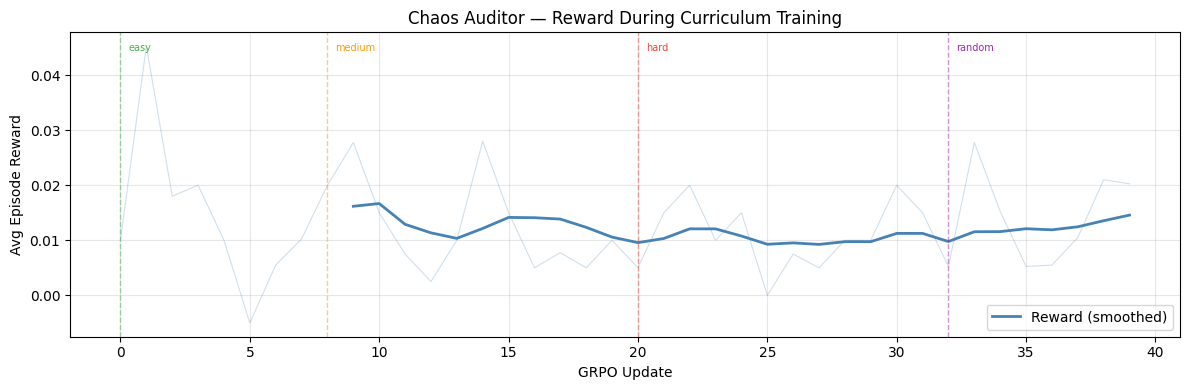

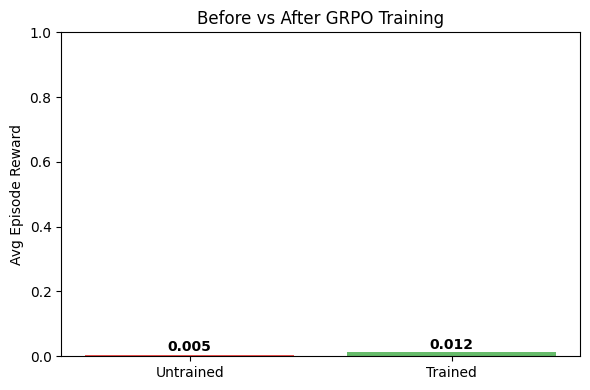

Plots saved and logged to wandb.


In [ ]:
# ── Cell 12: Plots ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

steps = list(range(len(all_rewards)))
colors = {"easy": "#4CAF50", "medium": "#FF9800", "hard": "#F44336", "random": "#9C27B0"}
window = 10

def smooth(data, w=10):
    return np.convolve(data, np.ones(w)/w, mode='valid')

def add_stage_lines(ax):
    for s, t in curriculum_markers:
        ax.axvline(x=s, color=colors.get(t, "gray"), linestyle="--", alpha=0.5, linewidth=1)
        ax.text(s+0.3, ax.get_ylim()[1]*0.93, t, fontsize=7, color=colors.get(t, "gray"))

# Reward curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, all_rewards, alpha=0.25, color="steelblue", linewidth=0.8)
if len(all_rewards) >= window:
    ax.plot(range(window-1, len(all_rewards)), smooth(all_rewards, window),
            color="steelblue", linewidth=2, label="Reward (smoothed)")
add_stage_lines(ax)
ax.set_xlabel("GRPO Update"); ax.set_ylabel("Avg Episode Reward")
ax.set_title("Chaos Auditor — Reward During Curriculum Training")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./metrics/reward_curve.png", dpi=150)
plt.show()

# Before vs After bar chart
trained_avg = np.mean(all_rewards[-20:]) if len(all_rewards) >= 20 else np.mean(all_rewards)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Untrained", "Trained"],
              [baseline.get("easy", 0), trained_avg],
              color=["#EF5350", "#66BB6A"])
for bar, val in zip(bars, [baseline.get("easy", 0), trained_avg]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", fontweight="bold")
ax.set_title("Before vs After GRPO Training")
ax.set_ylabel("Avg Episode Reward"); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("./metrics/before_after.png", dpi=150)
plt.show()

wandb.log({
    "plots/reward_curve":  wandb.Image("./metrics/reward_curve.png"),
    "plots/before_after":  wandb.Image("./metrics/before_after.png"),
})
print("Plots saved and logged to wandb.")

In [ ]:
# ── Cell 13: Eval on held-out seeds ───────────────────────────────────
import numpy as np

# Guard: if runtime was reset, these names will be missing
missing = [n for n in ["reset_env", "model", "SYSTEM_PROMPT"] if n not in dir()]
if missing:
    raise RuntimeError(
        f"Variables {missing} not defined — runtime was reset. "
        "Please run all cells from Cell 1 before running eval."
    )

print("Running eval on held-out seeds (seeds 100-109)...")
eval_rewards = {"easy": [], "medium": []}

for task in ["easy", "medium"]:
    for seed in range(100, 110):
        obs = reset_env(task, seed=seed)
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": obs.get("system_description", "") + "\n\nBegin your audit."},
        ]
        total_r = 0.0
        for step in range(12):
            if step > 0:
                messages.append({"role": "user", "content": (
                    f"Result: {obs.get('action_result','')}\n"
                    f"Budget: {obs.get('chaos_budget_remaining',0)} | Steps: {obs.get('steps_remaining',0)}"
                )})
            completion = generate_action(messages)
            messages.append({"role": "assistant", "content": completion})
            action = parse_action(completion)
            obs, reward, done = step_env(action)
            total_r += reward or 0.0
            if done:
                break
        eval_rewards[task].append(total_r)
        print(f"  {task} seed={seed}: reward={total_r:.3f}")

for task, rewards in eval_rewards.items():
    avg = np.mean(rewards)
    print(f"\n{task} eval avg: {avg:.3f}")
    wandb.log({f"eval/{task}/reward": avg})

wandb.finish()
print("\nEval done.")


Running eval on held-out seeds...


In [ ]:
# ── Cell 14: Save model to HuggingFace Hub ────────────────────────────
# With 4-bit QLoRA, merge_and_unload() dequantizes to float16 first.
# This is the correct pattern for bitsandbytes 4-bit + PEFT.

import torch
from peft import PeftModel

HF_MODEL_REPO = "adwikataware/chaos-auditor-qwen"

print("Saving LoRA adapters to Hub (adapter-only push — fast)...")
# Push adapters only — judges can load with: PeftModel.from_pretrained(base, repo)
model.push_to_hub(HF_MODEL_REPO, token=HF_TOKEN)
tokenizer.push_to_hub(HF_MODEL_REPO, token=HF_TOKEN)

print(f"Adapters saved to https://huggingface.co/{HF_MODEL_REPO}")
print("Load with: model = PeftModel.from_pretrained(base_model, HF_MODEL_REPO)")


In [ ]:
# ── Pipeline Summary ──────────────────────────────────────────────────
# Cell 1  — install deps (includes bitsandbytes for QLoRA)
# Cell 2  — config (model name, curriculum, hyperparams)
# Cell 3  — wandb init
# Cell 4  — load Qwen2.5-1.5B with 4-bit QLoRA + LoRA adapters
# Cell 5  — local ChaosAuditorEnvironment (no HTTP dependency)
# Cell 6  — system prompt
# Cell 7  — SFT warmup (4 demonstrations × 2 epochs)
# Cell 8  — helpers: parse_action, generate_action, run_episode
# Cell 9  — GRPO training loop (group relative policy gradient)
# Cell 9b — GPU memory cleanup
# Cell 10 — baseline measurement (pre-GRPO)
# Cell 11 — curriculum training (easy → medium → hard → random)
# Cell 12 — reward curve + before/after plots → wandb
# Cell 13 — eval on held-out seeds (seeds 100-109)
# Cell 14 — merge LoRA + push to HuggingFace Hub
print("All cells complete.")
